# Team Rodeo | Assignment 3#
Gustavo Wengerkiewicz Storck & Hesham Rashid

---

## Part 1

See PDF document.

In [ ]:
# Calling libraries and preprocessing

import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve
)

SAMPLE_DATA_PATH = "sample_data.csv"

# Load CSV with column names and NA handling
sampledf = pd.read_csv(SAMPLE_DATA_PATH, header=0, na_values="NA")

# Inspect first rows
print(sampledf.head())

# Check shape
print("Dataset shape:", sampledf.shape)

# Count missing values per column
print(sampledf.isna().sum())

   Company ID      DSRI       GMI       AQI        SGI      DEPI      SGAI  \
0           1  1.624742  1.128927  7.185053   0.366211  1.381519  1.624145   
1           2  1.000000  1.606492  1.004988  13.081433  0.400000  5.198207   
2           3  1.000000  1.015607  1.241389   1.475018  1.169353  0.647671   
3           4  1.486239  1.000000  0.465535   0.672840  2.000000  0.092890   
4           5  1.000000  1.369038  0.637112   0.861346  1.454676  1.741460   

       ACCR      LEVI Manipulator  C-MANIPULATOR  
0 -0.166809  1.161082         Yes              1  
1  0.060475  0.986732         Yes              1  
2  0.036732  1.264305         Yes              1  
3  0.273434  0.680975         Yes              1  
4  0.123048  0.939047         Yes              1  
Dataset shape: (220, 11)
Company ID       0
DSRI             0
GMI              0
AQI              0
SGI              0
DEPI             0
SGAI             0
ACCR             0
LEVI             0
Manipulator      0
C-MANIPULA

---

## Part 2

Use sample_data.csv (220 cases including 39 manipulators) and develop a logistic regression model that can be used by MCA Technologies Private Limited for predicting probability of earnings manipulation. Describe each step of building the model and explain the rationale when necessary.

In [ ]:
# Checked for missing values earlier: none found. No imputation needed.

# Define features and target. Used C-MANIPULATOR (1 = manipulator, 0 = non-manipulator) as the target variable.
X = sampledf[['DSRI', 'GMI', 'AQI', 'SGI', 'DEPI', 'SGAI', 'ACCR', 'LEVI']]
y = sampledf['C-MANIPULATOR']

# Train-test split (stratified to preserve 39 manipulators proportion)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Handle Class Imbalance and Scale Features
# Because manipulators are only ~18% of the data, we apply class weighting and feature scaling.
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Penalized logistic regression with class weights
logreg = LogisticRegression(
    class_weight='balanced',   # Handle imbalance automatically
    solver='liblinear',        # Ideal for small to medium datasets
    random_state=42
)
logreg.fit(X_train_scaled, y_train)

# Coefficients summary
coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': logreg.coef_[0],
    'Odds Ratio': np.exp(logreg.coef_[0])
}).sort_values(by='Odds Ratio', ascending=False)

print(coefficients)

# Interpretation of Coefficients:
# Positive coefficients → increase probability of manipulation.
# Odds ratios > 1 indicate that a unit increase in that variable increases the odds of being a manipulator.
# The strongest effects come from DSRI, AQI, GMI, and SGI, consistent with prior Beneish findings.
# For example, since  GMI has an odds ratio of 4.5, higher gross margin index is linked to higher manipulation risk.


  Variable  Coefficient  Odds Ratio
0     DSRI     2.247374    9.462855
2      AQI     1.691822    5.429362
1      GMI     1.512034    4.535946
3      SGI     1.407070    4.083970
6     ACCR     0.723140    2.060894
4     DEPI     0.031151    1.031641
5     SGAI    -0.023182    0.977085
7     LEVI    -0.103723    0.901475


---

## Part 3

Comment on the model you developed by explaining the results; how do you measure the accuracy of the model?

[[50  4]
 [ 5  7]]
              precision    recall  f1-score   support

           0      0.909     0.926     0.917        54
           1      0.636     0.583     0.609        12

    accuracy                          0.864        66
   macro avg      0.773     0.755     0.763        66
weighted avg      0.860     0.864     0.861        66

ROC-AUC: 0.924


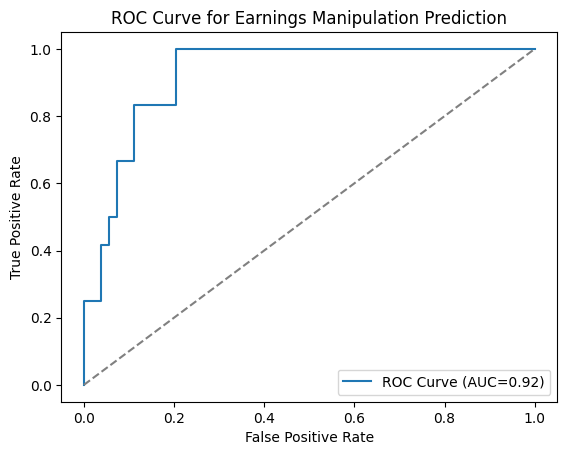

In [ ]:
import matplotlib.pyplot as plt

# Evaluate the model
# Predictions and probabilities
y_pred = logreg.predict(X_test_scaled)
y_prob = logreg.predict_proba(X_test_scaled)[:, 1]

# Confusion matrix & metrics
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

# AUC-ROC
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", round(roc_auc, 3))

# Plot the curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"ROC Curve (AUC={roc_auc:.2f})")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title('ROC Curve for Earnings Manipulation Prediction')
plt.show()

# The AUC = 0.92 indicates excellent discrimination between manipulators and non-manipulators.
# Accuracy = 86 % shows strong overall performance.
# The model correctly identifies 7 of 12 manipulators (recall = 0.583) while maintaining low false alarms (precision = 0.636).
# Non-manipulator predictions are very accurate (recall ≈ 0.93).
# For banking applications, recall on manipulators can be tuned higher by lowering the decision threshold (e.g., from 0.5 to 0.35) to catch more risky cases.


---

## Part 4

See PDF document.

---

## Part 5

See PDF document.

---

## Part 6

Develop classification and regression tree (CART) model. Describe each step of building the model and explain the rationale when necessary. What insights do you obtain from the CART model?

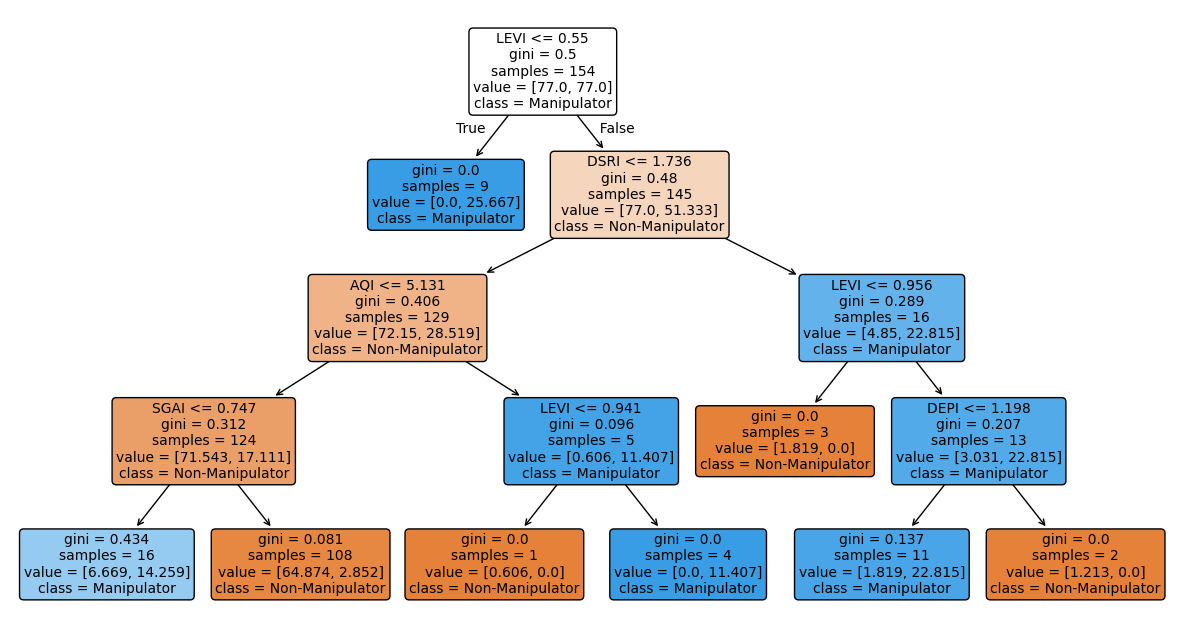

In [ ]:
# CART Algorithm

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier # Import DecisionTreeClassifier

cart_model = DecisionTreeClassifier(
    criterion='gini',        # Gini impurity (common for classification)
    max_depth=4,             # Prevents overfitting
    min_samples_split=5,     # Minimum samples to further split
    class_weight='balanced', # Handle class imbalance
    random_state=42
)
cart_model.fit(X_train, y_train)

# Visualizing the tree

plt.figure(figsize=(15,8))
tree.plot_tree(
    cart_model,
    feature_names=X.columns,
    class_names=['Non-Manipulator', 'Manipulator'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

In [ ]:
# Evaluation of Results

y_pred = cart_model.predict(X_test)
y_prob = cart_model.predict_proba(X_test)[:,1]

# Performance metrics
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# Accuracy = 76 %: The model correctly classifies most companies overall, but that is mostly due to the abundance of non-manipulators in the data.
# ROC-AUC = 0.586: This is quite low, barely above random guessing (0.5).
# The model is not reliably distinguishing manipulators from non-manipulators.

# Minority-Class (Manipulator) Performance
  # Recall = 0.25 (25 %) → The model captures only 3 out of 12 manipulators.
  # Precision = 0.30 (30 %) → Only 30 % of companies flagged as manipulators are truly manipulators.

# Conclusion:
  # The tree confirms the same red-flag variables highlighted by the logistic regression model (DSRI, AQI, LEVI, DEPI).
  # However, it is too deterministic. It classifies based on hard thresholds, which explains its low recall (0.25) and low AUC (0.59).



[[47  7]
 [ 9  3]]
              precision    recall  f1-score   support

           0       0.84      0.87      0.85        54
           1       0.30      0.25      0.27        12

    accuracy                           0.76        66
   macro avg       0.57      0.56      0.56        66
weighted avg       0.74      0.76      0.75        66

ROC-AUC: 0.5864197530864197


## Part 7

Develop a logistic regression model using the complete_data.csv (1200 non-manipulators and 39
manipulators), compare the results with the previous logistic regression model.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                            roc_auc_score, roc_curve, accuracy_score,
                            precision_score, recall_score, f1_score)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt



df_complete = pd.read_csv('complete_data.csv')

# Features: Only the 8 Beneish M-Score ratios
feature_columns = ['DSRI', 'GMI', 'AQI', 'SGI', 'DEPI', 'SGAI', 'ACCR', 'LEVI']

X_complete = df_complete[feature_columns].copy()
y_complete = df_complete['Manipulater'].apply(lambda x: 1 if x == 'Yes' else 0)

# Handle any missing or infinite values
X_complete = X_complete.replace([np.inf, -np.inf], np.nan)
for col in X_complete.columns:
    if X_complete[col].isnull().sum() > 0:
        median_val = X_complete[col].median()
        X_complete[col].fillna(median_val, inplace=True)

print(f"Dataset Shape: {X_complete.shape}")
print(f"\nClass Distribution:")
print(f"Non-manipulators (0): {(y_complete == 0).sum()}")
print(f"Manipulators (1): {(y_complete == 1).sum()}")
print(f"Imbalance Ratio: {(y_complete == 0).sum() / (y_complete == 1).sum():.2f}:1")



print("\n" )
print("Train-Test Split (80-20)")


X_train, X_test, y_train, y_test = train_test_split(
    X_complete, y_complete,
    test_size=0.2,
    random_state=42,
    stratify=y_complete
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training manipulators: {y_train.sum()}")
print(f"Test manipulators: {y_test.sum()}")



scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#  Standard Logistical Regression

print("\n" )
print("Standard Logistical Regression")


lr_standard = LogisticRegression(random_state=42, max_iter=1000)
lr_standard.fit(X_train_scaled, y_train)

y_pred_standard = lr_standard.predict(X_test_scaled)
y_pred_proba_standard = lr_standard.predict_proba(X_test_scaled)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred_standard))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_standard):.4f}")
print("\nConfusion Matrix:")
cm_standard = confusion_matrix(y_test, y_pred_standard)
print(cm_standard)


# Logistical Regression with Class Weights

print("\n" )
print("Logistical Regression with Class Weights (Complete Data)")


lr_weighted = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)
lr_weighted.fit(X_train_scaled, y_train)

y_pred_weighted = lr_weighted.predict(X_test_scaled)
y_pred_proba_weighted = lr_weighted.predict_proba(X_test_scaled)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred_weighted))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_weighted):.4f}")
print("\nConfusion Matrix:")
cm_weighted = confusion_matrix(y_test, y_pred_weighted)
print(cm_weighted)


# Logistical Regression with SMOTE

print("\n" )
print("Logistical Regression with SMOTE (Complete Data)")


smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"After SMOTE - Training set size: {X_train_smote.shape[0]}")
print(f"After SMOTE - Class distribution:")
print(f"  Non-manipulators: {(y_train_smote == 0).sum()}")
print(f"  Manipulators: {(y_train_smote == 1).sum()}")

lr_smote = LogisticRegression(random_state=42, max_iter=1000)
lr_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = lr_smote.predict(X_test_scaled)
y_pred_proba_smote = lr_smote.predict_proba(X_test_scaled)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_smote):.4f}")
print("\nConfusion Matrix:")
cm_smote = confusion_matrix(y_test, y_pred_smote)
print(cm_smote)


# Complete Data Model Comparison

print("\n" )
print("Complete Data Model Comparison")


results_complete = {
    'Model': ['Standard LR', 'Weighted LR', 'SMOTE LR'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_standard),
        accuracy_score(y_test, y_pred_weighted),
        accuracy_score(y_test, y_pred_smote)
    ],
    'Precision': [
        precision_score(y_test, y_pred_standard, zero_division=0),
        precision_score(y_test, y_pred_weighted, zero_division=0),
        precision_score(y_test, y_pred_smote, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_pred_standard, zero_division=0),
        recall_score(y_test, y_pred_weighted, zero_division=0),
        recall_score(y_test, y_pred_smote, zero_division=0)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_standard, zero_division=0),
        f1_score(y_test, y_pred_weighted, zero_division=0),
        f1_score(y_test, y_pred_smote, zero_division=0)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_proba_standard),
        roc_auc_score(y_test, y_pred_proba_weighted),
        roc_auc_score(y_test, y_pred_proba_smote)
    ]
}

comparison_complete_df = pd.DataFrame(results_complete)
print("\n", comparison_complete_df.to_string(index=False))


# Feature Coefficients Comparison

print("\n")
print("Feature Coefficients Comparison: Question 2 (sample data) vs Question 7(complete data)")


# Sample Data (from sample_data.csv - 220 cases)
q2_coefficients = {
    'DSRI': 2.247374,
    'GMI': 1.512034,
    'AQI': 1.691822,
    'SGI': 1.407070,
    'DEPI': 0.031151,
    'SGAI': -0.023182,
    'ACCR': 0.723140,
    'LEVI': -0.103723
}

q2_odds_ratios = {
    'DSRI': 9.462855,
    'GMI': 4.535946,
    'AQI': 5.429362,
    'SGI': 4.083970,
    'DEPI': 1.031641,
    'SGAI': 0.977085,
    'ACCR': 2.060894,
    'LEVI': 0.901475
}

# Complete Data coefficients (from complete_data.csv - 1239 cases)
q7_coefficients = dict(zip(feature_columns, lr_standard.coef_[0]))
q7_odds_ratios = dict(zip(feature_columns, np.exp(lr_standard.coef_[0])))

# Create comparison dataframe
coef_comparison = pd.DataFrame({
    'Feature': feature_columns,
    'Q2_Coefficient': [q2_coefficients[f] for f in feature_columns],
    'Q7_Coefficient': [q7_coefficients[f] for f in feature_columns],
    'Difference': [q7_coefficients[f] - q2_coefficients[f] for f in feature_columns],
    'Q2_Odds_Ratio': [q2_odds_ratios[f] for f in feature_columns],
    'Q7_Odds_Ratio': [q7_odds_ratios[f] for f in feature_columns]
})

# Sort by absolute Q7 coefficient
coef_comparison['Abs_Q7_Coef'] = np.abs(coef_comparison['Q7_Coefficient'])
coef_comparison = coef_comparison.sort_values('Abs_Q7_Coef', ascending=False)
coef_comparison = coef_comparison.drop('Abs_Q7_Coef', axis=1)

print("\n", coef_comparison.to_string(index=False))


# Sample Data VS Complete Data Comparison

print("\n")
print("Sample Data VS Complete Data Comparison")


print("\nDataset Characteristics:")
print(f"{'Metric':<30} {'Sample Data (Q2)':<20} {'Complete Data (Q7)':<20}")
print("-" * 70)
print(f"{'Total Cases':<30} {'220':<20} {len(y_complete):<20}")
print(f"{'Manipulators':<30} {'39':<20} {(y_complete == 1).sum():<20}")
print(f"{'Non-manipulators':<30} {'181':<20} {(y_complete == 0).sum():<20}")
print(f"{'Manipulator %':<30} {'17.7%':<20} {f'{100*y_complete.mean():.1f}%':<20}")
print(f"{'Imbalance Ratio':<30} {'4.6:1':<20} {f'{(y_complete == 0).sum() / (y_complete == 1).sum():.1f}:1':<20}")



Dataset Shape: (1239, 8)

Class Distribution:
Non-manipulators (0): 1200
Manipulators (1): 39
Imbalance Ratio: 30.77:1


Train-Test Split (80-20)
Training set size: 991
Test set size: 248
Training manipulators: 31
Test manipulators: 8


Standard Logistical Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       240
           1       1.00      0.25      0.40         8

    accuracy                           0.98       248
   macro avg       0.99      0.62      0.69       248
weighted avg       0.98      0.98      0.97       248

ROC-AUC Score: 0.9094

Confusion Matrix:
[[240   0]
 [  6   2]]


Logistical Regression with Class Weights (Complete Data)

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.85      0.92       240
           1       0.12      0.62      0.21         8

    accuracy                           0.85       248
   macro avg    

## Part 8
Develop models using machine learning algorithms such as random forest and boosting (or even more
than these two). Using appropriate evaluation approaches to compare the outputs from these methods
with logistic regression and classification tree.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             accuracy_score, precision_score, recall_score, f1_score)
import pandas as pd
import numpy as np

df = pd.read_csv('complete_data.csv')
X = df.drop(['Company ID', 'Manipulater', 'C-MANIPULATOR'], axis=1)
y = df['Manipulater']

# Convert 'Yes' to 1, everything else to 0
y = (y == 'Yes').astype(int)

print(f"Features shape: {X.shape}")
print(f"Feature columns: {list(X.columns)}")
print(f"\nTarget distribution:\n{y.value_counts()}")
print(f"Class balance: {y.value_counts(normalize=True)}")

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"\nAfter SMOTE - Train set size: {X_train_resampled.shape[0]}")
print(f"After SMOTE - Class distribution:\n{pd.Series(y_train_resampled).value_counts()}")

# Initialize results dictionary
results = {}

# Random Forest
print("\n")
print("Random Forest")


rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train on resampled data
rf.fit(X_train_resampled, y_train_resampled)

# Predict on original test set
y_pred_rf = rf.predict(X_test_scaled)
y_pred_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

# Evaluate
results['Random Forest'] = {
    'model': rf,
    'y_pred': y_pred_rf,
    'y_pred_proba': y_pred_proba_rf,
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf),
    'recall': recall_score(y_test, y_pred_rf),
    'f1': f1_score(y_test, y_pred_rf),
    'roc_auc': roc_auc_score(y_test, y_pred_proba_rf)
}

print(f"Accuracy: {results['Random Forest']['accuracy']:.4f}")
print(f"Precision: {results['Random Forest']['precision']:.4f}")
print(f"Recall: {results['Random Forest']['recall']:.4f}")
print(f"F1-Score: {results['Random Forest']['f1']:.4f}")
print(f"ROC-AUC: {results['Random Forest']['roc_auc']:.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

# Gradient Boosting
print("\n")
print("Gradient Boosting")


gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=42
)

# Train on resampled data
gb.fit(X_train_resampled, y_train_resampled)

# Predict on original test set
y_pred_gb = gb.predict(X_test_scaled)
y_pred_proba_gb = gb.predict_proba(X_test_scaled)[:, 1]

results['Gradient Boosting'] = {
    'model': gb,
    'y_pred': y_pred_gb,
    'y_pred_proba': y_pred_proba_gb,
    'accuracy': accuracy_score(y_test, y_pred_gb),
    'precision': precision_score(y_test, y_pred_gb),
    'recall': recall_score(y_test, y_pred_gb),
    'f1': f1_score(y_test, y_pred_gb),
    'roc_auc': roc_auc_score(y_test, y_pred_proba_gb)
}

print(f"Accuracy: {results['Gradient Boosting']['accuracy']:.4f}")
print(f"Precision: {results['Gradient Boosting']['precision']:.4f}")
print(f"Recall: {results['Gradient Boosting']['recall']:.4f}")
print(f"F1-Score: {results['Gradient Boosting']['f1']:.4f}")
print(f"ROC-AUC: {results['Gradient Boosting']['roc_auc']:.4f}")

# Model Comparison Summary
print("\n")
print("MODEL COMPARISON SUMMARY")


comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1-Score': [results[m]['f1'] for m in results.keys()],
    'ROC-AUC': [results[m]['roc_auc'] for m in results.keys()]
})

print("\n", comparison_df.to_string(index=False))

# Confusion Matrix for best model
from sklearn.metrics import confusion_matrix, classification_report

print("\n")
print("Confusion Matrix (Random Forest)")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

Features shape: (1239, 8)
Feature columns: ['DSRI', 'GMI', 'AQI', 'SGI', 'DEPI', 'SGAI', 'ACCR', 'LEVI']

Target distribution:
Manipulater
0    1200
1      39
Name: count, dtype: int64
Class balance: Manipulater
0    0.968523
1    0.031477
Name: proportion, dtype: float64

Train set size: 991
Test set size: 248

After SMOTE - Train set size: 1920
After SMOTE - Class distribution:
Manipulater
0    960
1    960
Name: count, dtype: int64


Random Forest
Accuracy: 0.8992
Precision: 0.1600
Recall: 0.5000
F1-Score: 0.2424
ROC-AUC: 0.9068

Top 10 Most Important Features:
  feature  importance
0    DSRI    0.230733
6    ACCR    0.206789
3     SGI    0.176186
7    LEVI    0.101517
1     GMI    0.094740
5    SGAI    0.081567
2     AQI    0.059674
4    DEPI    0.048793


Gradient Boosting
Accuracy: 0.9274
Precision: 0.2222
Recall: 0.5000
F1-Score: 0.3077
ROC-AUC: 0.9010


MODEL COMPARISON SUMMARY

             Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
    Random Forest  0.899194   0.1

## Part 9
See PDF document.